# Análise Exploratória de dados

- É a prática de colher, limpar, analisar e demostrar dados em busca de respostas e previsões 
- Dentre as etapas mais importantes do processo de análise de dados está:
    - Importar um conjunto de dados;
    - Compreender o quadro geral;
    - Preparação dos dados;
    - Compreensão das variáveis;
    - Estudo das relações entre variáveis;
    - Debate sobre o resultado;
- Não necessariamente precisamos seguir essa ordem ou usar todas essas etapas, essa escolha é individual para cada projeto, o problema a ser sanado e a solução encontrada;


In [1]:
# Importando um dataset:
import pandas as pd
import numpy as np
import seaborn as sns

# Defino a variável e uso o pandas pra importar o dataset:
df = pd.read_csv('/home/cassio/Documentos/programação/Senai/Carreira_Dados/modulo_2/Titanic-Dataset.csv')

# Imprimo as 5 primeiras linhas do dataset usando o método .head():
print(df.head())





   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## Começamos analisando as informações básicas do dataset:

In [2]:
# Tabela com o tipo de cada dado:
print(f'Tabela com .info():\n{df.info()}\n')
print(f'Tabela com .dtype():\n{df.dtypes}\n')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Tabela com .info():
None

Tabela com .dtype():
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare 

In [ ]:
#Tabela com informações de estatística descritiva 
print(df.describe())

## Filtros


- Podemos filtrar por elementos dentro de uma coluna específica do dataset


In [3]:
# Aplicando filtro 
print(df[df['Age'] >= 10].head(10)) # Defino 10 dentro do .head pra ele me retornar as 10 primeiras do dataset

    PassengerId  Survived  Pclass  \
0             1         0       3   
1             2         1       1   
2             3         1       3   
3             4         1       1   
4             5         0       3   
6             7         0       1   
8             9         1       3   
9            10         1       2   
11           12         1       1   
12           13         0       3   

                                                 Name     Sex   Age  SibSp  \
0                             Braund, Mr. Owen Harris    male  22.0      1   
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                              Heikkinen, Miss. Laina  female  26.0      0   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                            Allen, Mr. William Henry    male  35.0      0   
6                             McCarthy, Mr. Timothy J    male  54.0      0   
8   Johnson, Mrs. Oscar W (Elisabeth Vilhelmin

- Filtramos as linhas duplicadas:

In [4]:
# Defino a variável onde vai ficar a lista de duplicados
duplicados = df[df.duplicated()]
print(duplicados)
print()

# O método .len() retorna a quantidade total de duplicados, se houver
print(f'Total de duplicados:\n{len(duplicados)}')

Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []

Total de duplicados:
0


- Caso hajam dados é importante tomarmos certas atitudes a fim evitar que na hora da tomada de decisão tendo esses dados como base, tenhams algum viés equivocado

In [5]:
# Para remover os duplicados, usamos a propriedade drop_duplicates()
df.drop_duplicates(keep='last', inplace=True) # Atributo keep indica qual dos duplicados será mantido, nesse caso o último
                                # inplace define que tudo seja salvo

- Precisamos corrigir se existem valores nulos;
- Esses valores podem trazer algum viés na hora da aplicação de um modelo;
- Usamos a propriedade .isnull().sum() para trazer a quantidade de nulos do dataset;

In [7]:
#Primeiro busco a quantidade
print(f'Número de NaNs:\n{df.isnull().sum()}\n')

# Eliminando os NaNs
    #df.dropna(subset=['Cabin'], inplace=True)
    #print(f'Número de NaNs:\n{df.isnull().sum()}\\n')


# Trocando os NaNs por 0:
df.replace(np.nan, '0', inplace=True)
print(f'Número de NaNs pós tratamento:\n{df.isnull().sum()}\\n')


Número de NaNs:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Número de NaNs pós tratamento:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64\n


## Feature Engenier


- Renomear colunas


In [8]:
df = df.rename(columns={'Survived': 'Sobrevivente'})
df = df.rename(columns={'Name': 'Nome'})
df = df.rename(columns={'Sex': 'Genero'})

# Posso colocar mais de um nome de coluna no mesmo argumento

df = df.rename(columns={'Age': 'Idade', 'Ticket': 'Bilhete', 'Cabin': 'Cabine'})

df.info()  # Visualizar as mudanças

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   891 non-null    int64  
 1   Sobrevivente  891 non-null    int64  
 2   Pclass        891 non-null    int64  
 3   Nome          891 non-null    str    
 4   Genero        891 non-null    str    
 5   Idade         891 non-null    object 
 6   SibSp         891 non-null    int64  
 7   Parch         891 non-null    int64  
 8   Bilhete       891 non-null    str    
 9   Fare          891 non-null    float64
 10  Cabine        891 non-null    str    
 11  Embarked      891 non-null    str    
dtypes: float64(1), int64(5), object(1), str(5)
memory usage: 83.7+ KB


- Podemos também reordenar as colunas:

In [ ]:
sorted_df = df.sort_values(by='PassengerId', ascending=True) # Em by, coloco qual a coluna e em ascending de vai ser ascendente ou não  

print(sorted_df)


## Outliers


- Refere-se a valores discrepantes, muito distantes das médias e medianas
- Mante-los pode interferir no resultado na análise e manipular a tomada de decisão de maneira equivocada
- Podem ser muito altos ou muitos baixos
- São os principais causados de modelos imprecisos, por isso é importante removê-los
- Usamos boxplot para visualização dos outliers

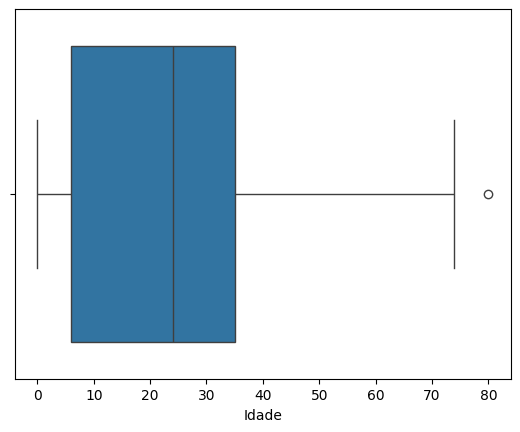

In [15]:
# No código

sns.boxplot(x=df['Idade'])

plt.show()

## Visualização dos dados

- Uma das partes mais importantes da análise dos dados é a plotagem para visualização dos dados através de gráficos, diagramas 
- Usaremos a propriedade `df['nome_da_coluna'].value_counts()` 

In [11]:
# Importo a biblioteca do matplotlib
import matplotlib.pyplot as plt

# Defino a variável que vai receber a contagem
survived_counts = df['Sobrevivente'].value_counts()

print(survived_counts)

Sobrevivente
0    549
1    342
Name: count, dtype: int64


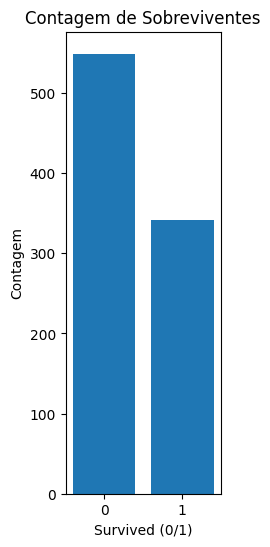

In [14]:
# montando o gráfico

plt.figure(figsize=(2,6))
plt.bar(survived_counts.index, survived_counts)

plt.title('Contagem de Sobreviventes')
plt.xlabel('Survived (0/1)')
plt.ylabel('Contagem')

plt.show()